---
### 04. 이진분류 모델
---

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from google.colab import drive
import os
drive.mount('/content/drive')
os.chdir('/content/drive/MyDrive/10Days_Pytorch')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import *
import torch
from torch import nn
from torch.utils.data import TensorDataset, DataLoader
from torch.optim import Adam

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(device)

Mounted at /content/drive
cpu


#### functions : Dataset, Train, Evaluate, Visualize

In [3]:
def make_DataSet(X_train, X_val, y_train, y_val, batch_size=32):
  X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
  y_train_tensor = torch.tensor(y_train, dtype=torch.float32).view(-1,1)
  X_val_tensor = torch.tensor(X_val, dtype=torch.float32)
  y_val_tensor = torch.tensor(y_val, dtype=torch.float32).view(-1,1)
  train_dataset = TensorDataset(X_train_tensor, y_train_tensor)

  train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
  return train_loader, X_val_tensor, y_val_tensor

In [4]:
def train(dataloader, model, loss_fn, optimizer, device):
  size = len(dataloader.dataset)
  num_batches = len(dataloader)
  tr_loss = 0

  model.train()
  for X, y in dataloader:
    X, y = X.to(device), y.to(device)

    pred = model(X)
    loss = loss_fn(pred, y)
    tr_loss += loss

    loss.backward()
    optimizer.step()
    optimizer.zero_grad()

  tr_loss /= num_batches
  return tr_loss.item()

In [5]:
def evaluate(X_val_tensor, y_val_tensor, model, loss_fn, device):
  model.eval()
  with torch.no_grad():
    X, y = X_val_tensor.to(device), y_val_tensor.to(device)
    pred = model(X)
    eval_loss = loss_fn(pred, y).item()
  return eval_loss, pred

In [26]:
def learning_curve(tr_loss_list, val_loss_list):
  epochs = list(range(1, len(tr_loss_list)+1))
  plt.plot(epochs, tr_loss_list, label='tr_err', marker='.')
  plt.plot(epochs, val_loss_list, label='val_err', marker='.')
  plt.xlabel('epochs')
  plt.ylabel('loss')
  plt.legend()
  plt.grid()
  plt.show()

### Data loading and Preprocessing
- titanic

In [12]:
# data loading
df = pd.read_csv('data/titanic.csv')
print(df.shape)
display(df.head(2))

# target and features
y = df['Survived']
X = df[['Sex', 'Age', 'Fare']]  # 3개 변수만 사용

# one-hot encoding
X = pd.get_dummies(X, columns=['Sex'], drop_first=True, dtype=int)

# split validation set
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# scaling
scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.fit_transform(X_val)

# y를 넘파이배열 전환(makeDataset 입력을 위해)
y_train = y_train.values
y_val = y_val.values

(712, 8)


,PassengerId,Survived,Pclass,Name,Sex,Age,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,7.2500,Southampton
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,71.2833,Cherbourg


### Modeling

In [13]:
# data loader
train_loader, X_val_ts, y_val_ts = make_DataSet(X_train, X_val, y_train, y_val, 32)

In [14]:
# model define
model = nn.Sequential(
    nn.Linear(X.shape[1], 1),
    nn.Sigmoid()
).to(device)

# loss_fn, opimizer
loss_fn = nn.BCELoss()
optimizer = Adam(model.parameters(), lr=0.01)

#### training and evaluation

In [16]:
epochs = 50
tr_loss_list, val_loss_list = [], []

for i in range(epochs):
  tr_loss = train(train_loader, model, loss_fn, optimizer, device)
  val_loss, _ = evaluate(X_val_ts, y_val_ts, model, loss_fn, device)

  tr_loss_list.append(tr_loss)
  val_loss_list.append(val_loss)
  print(f"epoch {i}, train loss: {tr_loss:.4f}, val loss: {val_loss:.4f}")

epoch 0, train loss: 0.6269, val loss: 0.6534
epoch 1, train loss: 0.6106, val loss: 0.6367
epoch 2, train loss: 0.5951, val loss: 0.6221
epoch 3, train loss: 0.5811, val loss: 0.6100
epoch 4, train loss: 0.5697, val loss: 0.5993
epoch 5, train loss: 0.5613, val loss: 0.5915
epoch 6, train loss: 0.5502, val loss: 0.5842
epoch 7, train loss: 0.5429, val loss: 0.5796
epoch 8, train loss: 0.5376, val loss: 0.5751
epoch 9, train loss: 0.5342, val loss: 0.5698
epoch 10, train loss: 0.5294, val loss: 0.5667
epoch 11, train loss: 0.5244, val loss: 0.5645
epoch 12, train loss: 0.5201, val loss: 0.5617
epoch 13, train loss: 0.5197, val loss: 0.5595
epoch 14, train loss: 0.5163, val loss: 0.5577
epoch 15, train loss: 0.5148, val loss: 0.5559
epoch 16, train loss: 0.5146, val loss: 0.5550
epoch 17, train loss: 0.5116, val loss: 0.5526
epoch 18, train loss: 0.5114, val loss: 0.5534
epoch 19, train loss: 0.5067, val loss: 0.5523
epoch 20, train loss: 0.5062, val loss: 0.5512
epoch 21, train loss: 0

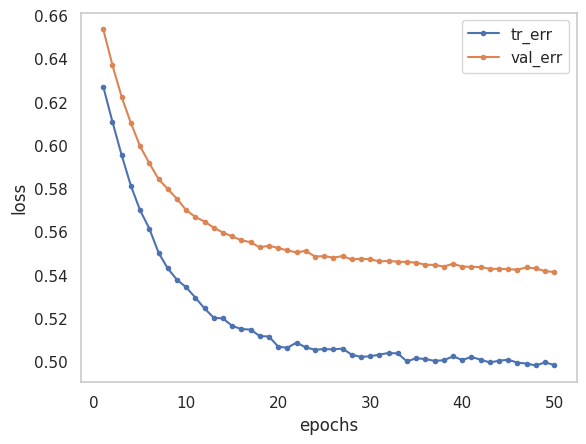

In [27]:
learning_curve(tr_loss_list, val_loss_list)

In [31]:
_, pred = evaluate(X_val_ts, y_val_ts, model, loss_fn, device)
print("Predicted %: ",'\n', pred.numpy()[:10])

pred2 = np.where(pred.numpy() > 0.5, 1, 0)
print("Predicted Survival", '\n', pred2[:10])

Predicted %:  
 [[0.7815638 ]
 [0.8010769 ]
 [0.26425123]
 [0.93847704]
 [0.18667866]
 [0.3001432 ]
 [0.715521  ]
 [0.87744236]
 [0.22417575]
 [0.6912903 ]]
Predicted Survival 
 [[1]
 [1]
 [0]
 [1]
 [0]
 [0]
 [1]
 [1]
 [0]
 [1]]


In [35]:
print(classification_report(y_val_ts.numpy(), pred2))

              precision    recall  f1-score   support

         0.0       0.76      0.85      0.80        80
         1.0       0.77      0.65      0.71        63

    accuracy                           0.76       143
   macro avg       0.76      0.75      0.75       143
weighted avg       0.76      0.76      0.76       143



---
## 은닉층 추가
- makeDataSet, DataLoader등 함수는 그대로 사용
- 모든 변수 사용
---

In [37]:
# data loading
df = pd.read_csv('data/titanic.csv')
print(df.shape)
display(df.head(2))

# target and features
y = df['Survived']
X = df.drop(['PassengerId', 'Name', 'Survived'], axis=1)

# one-hot encoding
obj_cols = ['Pclass', 'Sex', 'Embarked']
X = pd.get_dummies(X, columns=obj_cols, drop_first=True, dtype=int)

# split validation set
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# scaling
scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.fit_transform(X_val)

# y를 넘파이배열 전환(makeDataset 입력을 위해)
y_train = y_train.values
y_val = y_val.values

(712, 8)


,PassengerId,Survived,Pclass,Name,Sex,Age,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,7.2500,Southampton
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,71.2833,Cherbourg


In [40]:
# modeling
train_loader, X_val_ts, y_val_ts = make_DataSet(X_train, X_val, y_train, y_val, 32)

model = nn.Sequential(
    nn.Linear(X.shape[1], 5),
    nn.ReLU(),
    nn.Linear(5, 1),
    nn.Sigmoid()
).to(device)

loss_fn = nn.BCELoss()
optimizer = Adam(model.parameters(), lr=0.01)

In [41]:
# train
epochs = 50
tr_loss_list, val_loss_list = [], []

for i in range(epochs):
  tr_loss = train(train_loader, model, loss_fn, optimizer, device)
  val_loss, _ = evaluate(X_val_ts, y_val_ts, model, loss_fn, device)

  tr_loss_list.append(tr_loss)
  val_loss_list.append(val_loss)
  print(f"epoch {i}, tr loss: {tr_loss:.4f}, val loss: {val_loss:.4f}")

epoch 0, tr loss: 0.6354, val loss: 0.6465
epoch 1, tr loss: 0.5872, val loss: 0.6019
epoch 2, tr loss: 0.5447, val loss: 0.5717
epoch 3, tr loss: 0.5065, val loss: 0.5488
epoch 4, tr loss: 0.4833, val loss: 0.5455
epoch 5, tr loss: 0.4681, val loss: 0.5356
epoch 6, tr loss: 0.4627, val loss: 0.5356
epoch 7, tr loss: 0.4587, val loss: 0.5313
epoch 8, tr loss: 0.4530, val loss: 0.5258
epoch 9, tr loss: 0.4492, val loss: 0.5245
epoch 10, tr loss: 0.4479, val loss: 0.5200
epoch 11, tr loss: 0.4480, val loss: 0.5185
epoch 12, tr loss: 0.4419, val loss: 0.5120
epoch 13, tr loss: 0.4415, val loss: 0.5114
epoch 14, tr loss: 0.4380, val loss: 0.5118
epoch 15, tr loss: 0.4368, val loss: 0.5095
epoch 16, tr loss: 0.4353, val loss: 0.5071
epoch 17, tr loss: 0.4342, val loss: 0.5027
epoch 18, tr loss: 0.4344, val loss: 0.5080
epoch 19, tr loss: 0.4309, val loss: 0.5049
epoch 20, tr loss: 0.4291, val loss: 0.5037
epoch 21, tr loss: 0.4293, val loss: 0.5067
epoch 22, tr loss: 0.4288, val loss: 0.499

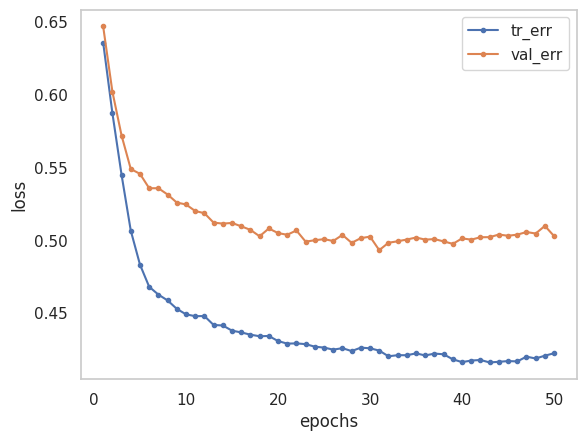

In [42]:
learning_curve(tr_loss_list, val_loss_list)

In [46]:
_, pred = evaluate(X_val_ts, y_val_ts, model, loss_fn, device)
pred = np.where(pred.numpy() >0.5, 1,0)

print(classification_report(y_val_ts.numpy(), pred))

              precision    recall  f1-score   support

         0.0       0.75      0.96      0.84        80
         1.0       0.93      0.59      0.72        63

    accuracy                           0.80       143
   macro avg       0.84      0.77      0.78       143
weighted avg       0.83      0.80      0.79       143

